# Dimension scaling relationship: p, m, and d

This exploratory study asks what the Forest Sketch target dimension `d` should scale with. We distinguish three widths:

- `p`: the original dataset feature count seen by the initial projection;
- `m`: the uncompressed visited-node/path feature width of the fitted random forest, i.e. the sum of the node counts of its trees;
- `d`: the target width of each Forest Sketch projection block.

The central comparison is whether competitiveness with the raw random-forest baseline is more stable as a function of `d/p`, `d/m`, absolute `d`, or none of these. We vary controlled synthetic input widths, include the scikit-learn breast-cancer dataset as a real reference, vary `n_estimators`, and sweep through dimensions below and above `p`, including `d=8192`.

This is exploratory evidence, not a proof. The default grid is intentionally bounded. Set `FORESTSKETCH_QUICK=1` for a smaller smoke run.

In [1]:
import os
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.random_projection import DataDimensionalityWarning

notebooks_dir = Path.cwd() / "notebooks"
if not (notebooks_dir / "_hypothesis_utils.py").exists():
    notebooks_dir = Path.cwd()
sys.path.insert(0, str(notebooks_dir))

from forestsketch import ForestSketchEstimator
from _hypothesis_utils import serialized_size_mb

warnings.filterwarnings(
    "ignore",
    category=DataDimensionalityWarning,
    message="The number of components is higher than the number of features.*",
)

QUICK = os.environ.get("FORESTSKETCH_QUICK", "0").lower() in {"1", "true", "yes"}
print(f"quick mode: {QUICK}")

quick mode: False


In [2]:
# The full run is 4 datasets x 2 forest sizes x 6 dimensions x 2 paired seeds.
# Sparse path projections keep the d=8192 stress point bounded while retaining
# the same Forest Sketch estimator and making the projection choice explicit.
DIMENSIONS = [8, 32, 128, 512, 2048, 8192]
DATASET_NAMES = ["synthetic_p12", "synthetic_p48", "synthetic_p120", "breast_cancer_p30"]
FOREST_SIZES = [16, 64]
SEEDS = [0, 1]
N_SAMPLES = 900

if QUICK:
    DATASET_NAMES = DATASET_NAMES[:2]
    FOREST_SIZES = [8, 16]
    DIMENSIONS = [8, 128, 8192]
    SEEDS = [0]
    N_SAMPLES = 600

def make_dataset(name, seed):
    if name.startswith("synthetic_"):
        p = int(name.removeprefix("synthetic_p"))
        informative = min(max(2, p // 6), p - 1)
        redundant = min(max(0, p // 5), p - informative)
        X, y = make_classification(
            n_samples=N_SAMPLES,
            n_features=p,
            n_informative=informative,
            n_redundant=redundant,
            n_repeated=0,
            n_classes=2,
            class_sep=0.8,
            flip_y=0.03,
            random_state=seed,
        )
    else:
        data = load_breast_cancer()
        X, y = data.data, data.target
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=seed + 1000
    )
    return X_train, X_test, y_train, y_test

def forest(seed, n_estimators):
    return RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=8,
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=seed,
    )

def downstream(seed):
    return make_pipeline(
        StandardScaler(with_mean=False),
        LogisticRegression(max_iter=1000, solver="liblinear", random_state=seed),
    )

def representation_mb(value):
    if hasattr(value, "data") and hasattr(value, "indices") and hasattr(value, "indptr"):
        return (value.data.nbytes + value.indices.nbytes + value.indptr.nbytes) / 2**20
    return np.asarray(value).nbytes / 2**20

def path_width(fitted_sketch):
    return int(sum(encoder.n_output_features_ for encoder in fitted_sketch.path_encoders_))

## Cost estimate before the sweep

Before launching the full grid, fit one planning forest per dataset/forest-size pair and measure its actual `m`. The table estimates the memory of a dense Gaussian path projection and of a sparse projection at scikit-learn's approximate density. The executed sweep uses sparse path projections and a non-materialized signed-hash concatenation projection, so the dense estimate is a warning signal rather than a claim about measured peak RSS.

In [3]:
planning_rows = []
for dataset_name in DATASET_NAMES:
    X_train, _, y_train, _ = make_dataset(dataset_name, 0)
    for n_estimators in FOREST_SIZES:
        planning_forest = forest(0, n_estimators).fit(X_train, y_train)
        m = int(sum(tree.tree_.node_count for tree in planning_forest.estimators_))
        for d in [min(DIMENSIONS), max(DIMENSIONS)]:
            dense_mb = d * m * 8 / 2**20
            sparse_density = min(1.0, 1.0 / np.sqrt(max(m, 1)))
            sparse_mb = d * m * sparse_density * 8 / 2**20
            planning_rows.append({
                "dataset": dataset_name,
                "p": X_train.shape[1],
                "n_estimators": n_estimators,
                "estimated_m": m,
                "d": d,
                "dense_gaussian_matrix_mb": dense_mb,
                "approx_sparse_matrix_mb": sparse_mb,
            })
planning = pd.DataFrame(planning_rows)
display(planning.round(1))
print("The sweep uses sparse path projection and signed-hash concatenation to avoid materializing the largest dense matrices.")

,dataset,p,n_estimators,estimated_m,d,dense_gaussian_matrix_mb,approx_sparse_matrix_mb
0,synthetic_p12,12,16,1592,8,0.1,0.0
1,synthetic_p12,12,16,1592,8192,99.5,2.5
2,synthetic_p12,12,64,6366,8,0.4,0.0
3,synthetic_p12,12,64,6366,8192,397.9,5.0
4,synthetic_p48,48,16,1544,8,0.1,0.0
5,synthetic_p48,48,16,1544,8192,96.5,2.5
6,synthetic_p48,48,64,6348,8,0.4,0.0
7,synthetic_p48,48,64,6348,8192,396.8,5.0
8,synthetic_p120,120,16,1630,8,0.1,0.0
9,synthetic_p120,120,16,1630,8192,101.9,2.5


The sweep uses sparse path projection and signed-hash concatenation to avoid materializing the largest dense matrices.


## Paired experiment

Every seed defines one reproducible train/test split per dataset, and the same seed is reused for the raw forest and every projection dimension. Each row records the exact fitted path width `m`, the ratios `d/p` and `d/m`, held-out accuracy, separate fit/transform/evaluation wall times, an output-memory proxy, serialized estimator size, and a failure status. The downstream classifier is logistic regression with sparse-safe standardization.

In [4]:
experiment_start = time.perf_counter()
rows = []

for dataset_name in DATASET_NAMES:
    for seed in SEEDS:
        X_train, X_test, y_train, y_test = make_dataset(dataset_name, seed)
        p = int(X_train.shape[1])
        n_samples = int(X_train.shape[0] + X_test.shape[0])
        for n_estimators in FOREST_SIZES:
            raw_model = forest(seed, n_estimators)
            raw_start = time.perf_counter()
            raw_model.fit(X_train, y_train)
            raw_fit_seconds = time.perf_counter() - raw_start
            raw_start = time.perf_counter()
            raw_accuracy = float(accuracy_score(y_test, raw_model.predict(X_test)))
            raw_eval_seconds = time.perf_counter() - raw_start

            for d in DIMENSIONS:
                base = {
                    "dataset": dataset_name,
                    "seed": seed,
                    "n_samples": n_samples,
                    "p": p,
                    "n_estimators": n_estimators,
                    "d": d,
                    "raw_rf_accuracy": raw_accuracy,
                    "raw_rf_fit_seconds": raw_fit_seconds,
                    "raw_rf_eval_seconds": raw_eval_seconds,
                    "status": "ok",
                }
                try:
                    sketch = ForestSketchEstimator(
                        estimator=forest(seed, n_estimators),
                        n_components=d,
                        n_iterations=1,
                        initial_projection_type="sparse",
                        path_projection_type="sparse",
                        concat_projection_type="signed_hash",
                        output_format="sparse",
                        random_state=seed,
                    )
                    fit_start = time.perf_counter()
                    train_view = sketch.fit_transform(X_train, y_train)
                    fit_seconds = time.perf_counter() - fit_start
                    transform_start = time.perf_counter()
                    test_view = sketch.transform(X_test)
                    transform_seconds = time.perf_counter() - transform_start
                    eval_start = time.perf_counter()
                    classifier = downstream(seed).fit(train_view, y_train)
                    sketch_accuracy = float(accuracy_score(y_test, classifier.predict(test_view)))
                    eval_seconds = time.perf_counter() - eval_start
                    m = path_width(sketch)
                    base.update({
                        "m": m,
                        "d_over_p": d / p,
                        "d_over_m": d / m,
                        "forest_sketch_accuracy": sketch_accuracy,
                        "fit_seconds": fit_seconds,
                        "transform_seconds": transform_seconds,
                        "evaluation_seconds": eval_seconds,
                        "output_train_mb": representation_mb(train_view),
                        "serialized_model_mb": serialized_size_mb(sketch),
                    })
                except Exception as exc:
                    base.update({
                        "m": np.nan,
                        "d_over_p": d / p,
                        "d_over_m": np.nan,
                        "forest_sketch_accuracy": np.nan,
                        "fit_seconds": np.nan,
                        "transform_seconds": np.nan,
                        "evaluation_seconds": np.nan,
                        "output_train_mb": np.nan,
                        "serialized_model_mb": np.nan,
                        "status": f"failed: {type(exc).__name__}: {exc}",
                    })
                rows.append(base)

results = pd.DataFrame(rows)
results["accuracy_gap_to_raw"] = results["forest_sketch_accuracy"] - results["raw_rf_accuracy"]
print(f"Total experiment wall-clock time: {time.perf_counter() - experiment_start:.1f} seconds")
print(f"Rows: {len(results)}, successful: {(results.status == 'ok').sum()}, failed: {(results.status != 'ok').sum()}")
display(results.head().round(4))

Total experiment wall-clock time: 41.2 seconds
Rows: 96, successful: 96, failed: 0


,dataset,seed,n_samples,p,n_estimators,d,raw_rf_accuracy,raw_rf_fit_seconds,raw_rf_eval_seconds,status,m,d_over_p,d_over_m,forest_sketch_accuracy,fit_seconds,transform_seconds,evaluation_seconds,output_train_mb,serialized_model_mb,accuracy_gap_to_raw
0,synthetic_p12,0,900,12,16,8,0.8593,0.0148,0.0146,ok,2220,0.6667,0.0036,0.6704,0.0302,0.0151,0.0012,0.0521,0.1815,-0.1889
1,synthetic_p12,0,900,12,16,32,0.8593,0.0148,0.0146,ok,1890,2.6667,0.0169,0.8111,0.0321,0.0144,0.0021,0.1981,0.1695,-0.0481
2,synthetic_p12,0,900,12,16,128,0.8593,0.0148,0.0146,ok,1650,10.6667,0.0776,0.8000,0.0421,0.0188,0.0056,0.7891,0.1986,-0.0593
3,synthetic_p12,0,900,12,16,512,0.8593,0.0148,0.0146,ok,1380,42.6667,0.3710,0.8037,0.0927,0.0326,0.0263,3.0642,0.3550,-0.0556
4,synthetic_p12,0,900,12,16,2048,0.8593,0.0148,0.0146,ok,1188,170.6667,1.7239,0.8407,0.2564,0.1278,0.1047,12.1084,1.0021,-0.0185


In [5]:
summary = (
    results[results.status == "ok"]
    .groupby(["dataset", "n_estimators", "d"], as_index=False)
    .agg(
        p=("p", "first"),
        m=("m", "mean"),
        d_over_p=("d_over_p", "first"),
        d_over_m=("d_over_m", "mean"),
        raw_accuracy=("raw_rf_accuracy", "mean"),
        sketch_accuracy=("forest_sketch_accuracy", "mean"),
        sketch_accuracy_std=("forest_sketch_accuracy", "std"),
        accuracy_gap=("accuracy_gap_to_raw", "mean"),
        fit_seconds=("fit_seconds", "mean"),
        transform_seconds=("transform_seconds", "mean"),
        evaluation_seconds=("evaluation_seconds", "mean"),
        output_train_mb=("output_train_mb", "mean"),
        serialized_model_mb=("serialized_model_mb", "mean"),
    )
)
display(summary.round(4))

,dataset,n_estimators,d,p,m,d_over_p,d_over_m,raw_accuracy,sketch_accuracy,sketch_accuracy_std,accuracy_gap,fit_seconds,transform_seconds,evaluation_seconds,output_train_mb,serialized_model_mb
0,breast_cancer_p30,16,8,30,611.0,0.2667,0.0131,0.9444,0.9035,0.0124,-0.0409,0.0282,0.0138,0.0011,0.0339,0.0568
1,breast_cancer_p30,16,32,30,504.0,1.0667,0.0641,0.9444,0.9181,0.0165,-0.0263,0.0312,0.0145,0.0016,0.1278,0.0566
2,breast_cancer_p30,16,128,30,418.0,4.2667,0.3072,0.9444,0.9298,0.0000,-0.0146,0.0350,0.0161,0.0035,0.4924,0.0780
3,breast_cancer_p30,16,512,30,353.0,17.0667,1.4556,0.9444,0.9386,0.0207,-0.0058,0.0541,0.0224,0.0117,1.9769,0.1809
4,breast_cancer_p30,16,2048,30,322.0,68.2667,6.3849,0.9444,0.9503,0.0207,0.0058,0.1286,0.0517,0.0495,7.7481,0.5972
5,breast_cancer_p30,16,8192,30,301.0,273.0667,27.3758,0.9444,0.9503,0.0124,0.0058,0.5466,0.2065,0.1852,31.0080,2.2311
6,breast_cancer_p30,64,8,30,2458.0,0.2667,0.0033,0.9444,0.9094,0.0207,-0.0351,0.0485,0.0151,0.0009,0.0349,0.2125
7,breast_cancer_p30,64,32,30,2121.0,1.0667,0.0152,0.9444,0.9415,0.0165,-0.0029,0.0475,0.0157,0.0014,0.1294,0.2015
8,breast_cancer_p30,64,128,30,1662.0,4.2667,0.0772,0.9444,0.9415,0.0083,-0.0029,0.0533,0.0172,0.0031,0.5044,0.2149
9,breast_cancer_p30,64,512,30,1486.0,17.0667,0.3456,0.9444,0.9444,0.0041,0.0000,0.0799,0.0240,0.0111,1.9974,0.3961


## Accuracy summaries

Curves are shown against both absolute `d` and normalized widths. The dotted line in each facet is the mean raw-forest accuracy for that dataset and forest size. Because this is a continuous two-factor grid rather than a small set of competing methods, no critical-difference diagram is forced here; the paired seed rows and mean/std summaries remain the appropriate primary report.

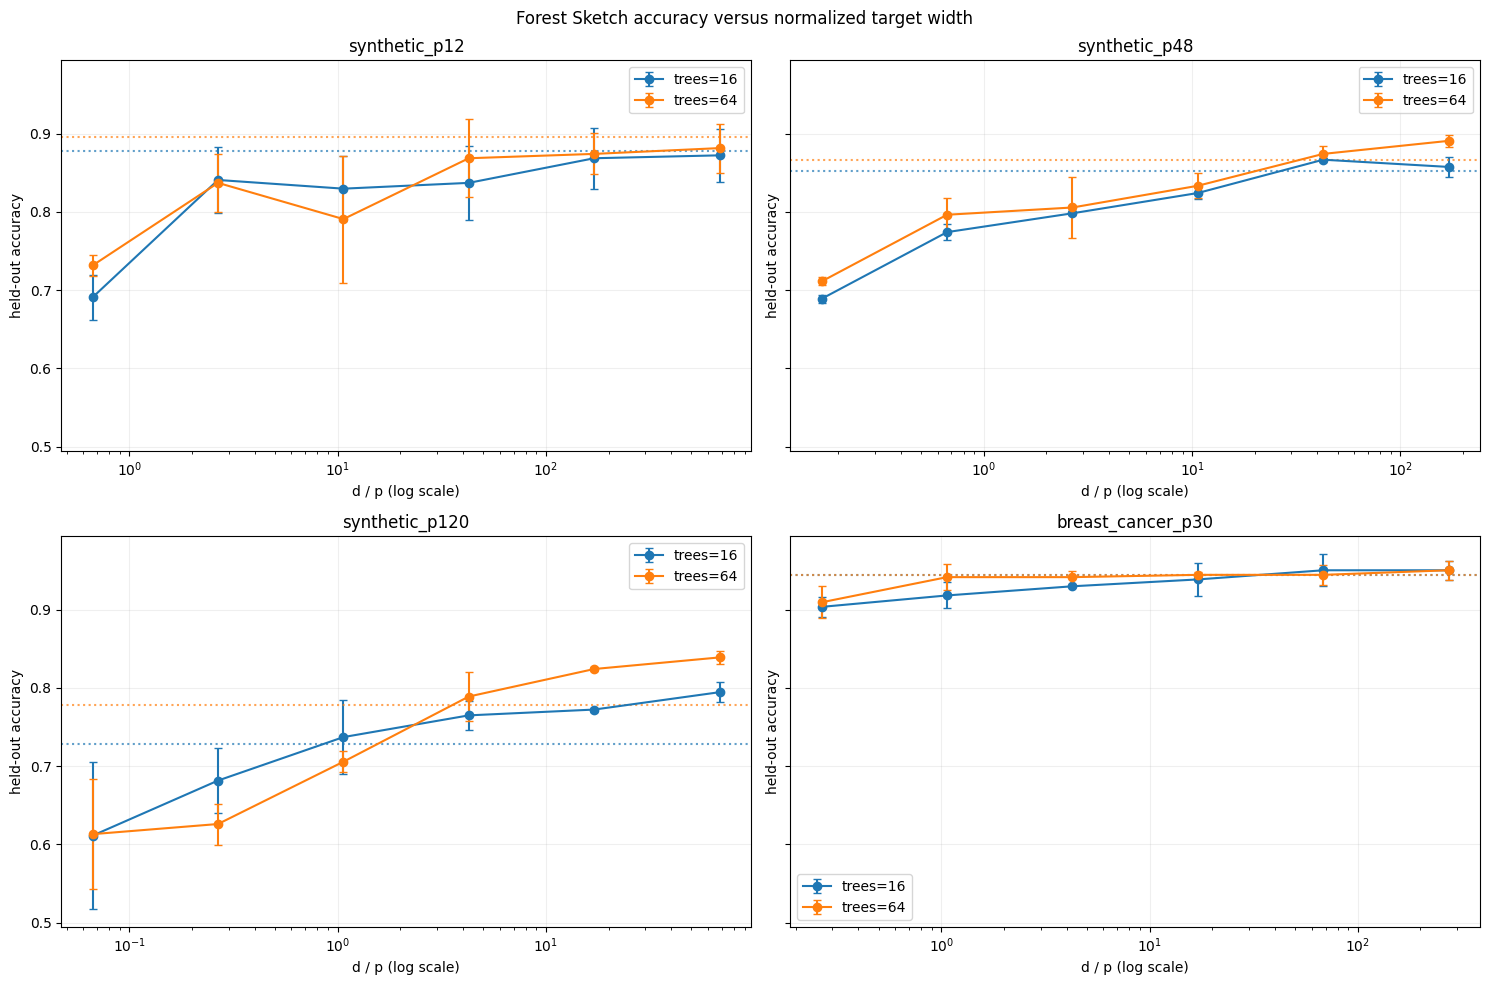

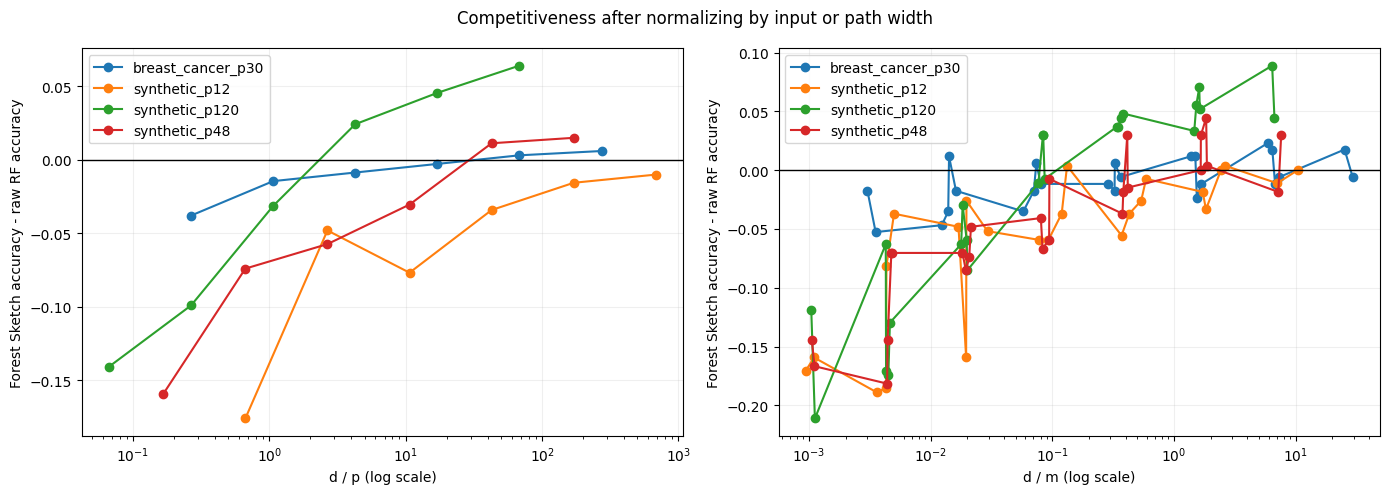

In [6]:
ok = results[results.status == "ok"].copy()
baseline = ok.groupby(["dataset", "n_estimators"], as_index=False)["raw_rf_accuracy"].mean()

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
for ax, dataset_name in zip(axes.ravel(), DATASET_NAMES):
    subset = ok[ok.dataset == dataset_name]
    for n_estimators, group in subset.groupby("n_estimators"):
        curve = group.groupby("d", as_index=False).agg(
            d_over_p=("d_over_p", "first"),
            d_over_m=("d_over_m", "mean"),
            accuracy=("forest_sketch_accuracy", "mean"),
            std=("forest_sketch_accuracy", "std"),
        )
        ax.errorbar(curve.d_over_p, curve.accuracy, yerr=curve["std"].fillna(0), marker="o", capsize=3, label=f"trees={n_estimators}")
        raw_value = baseline.loc[baseline.dataset.eq(dataset_name) & baseline.n_estimators.eq(n_estimators), "raw_rf_accuracy"].iloc[0]
        ax.axhline(raw_value, linestyle=":", color=ax.lines[-1].get_color(), alpha=0.7)
    ax.set_xscale("log")
    ax.set_title(dataset_name)
    ax.set_xlabel("d / p (log scale)")
    ax.set_ylabel("held-out accuracy")
    ax.grid(alpha=0.2)
    ax.legend()
fig.suptitle("Forest Sketch accuracy versus normalized target width")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, xcol, xlabel in zip(axes, ["d_over_p", "d_over_m"], ["d / p", "d / m"]):
    for dataset_name, group in ok.groupby("dataset"):
        curve = group.groupby(xcol, as_index=False)["accuracy_gap_to_raw"].mean().sort_values(xcol)
        ax.plot(curve[xcol], curve.accuracy_gap_to_raw, marker="o", label=dataset_name)
    ax.set_xscale("log")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_xlabel(f"{xlabel} (log scale)")
    ax.set_ylabel("Forest Sketch accuracy - raw RF accuracy")
    ax.grid(alpha=0.2)
    ax.legend()
fig.suptitle("Competitiveness after normalizing by input or path width")
fig.tight_layout()
plt.show()

## Width and cost scaling

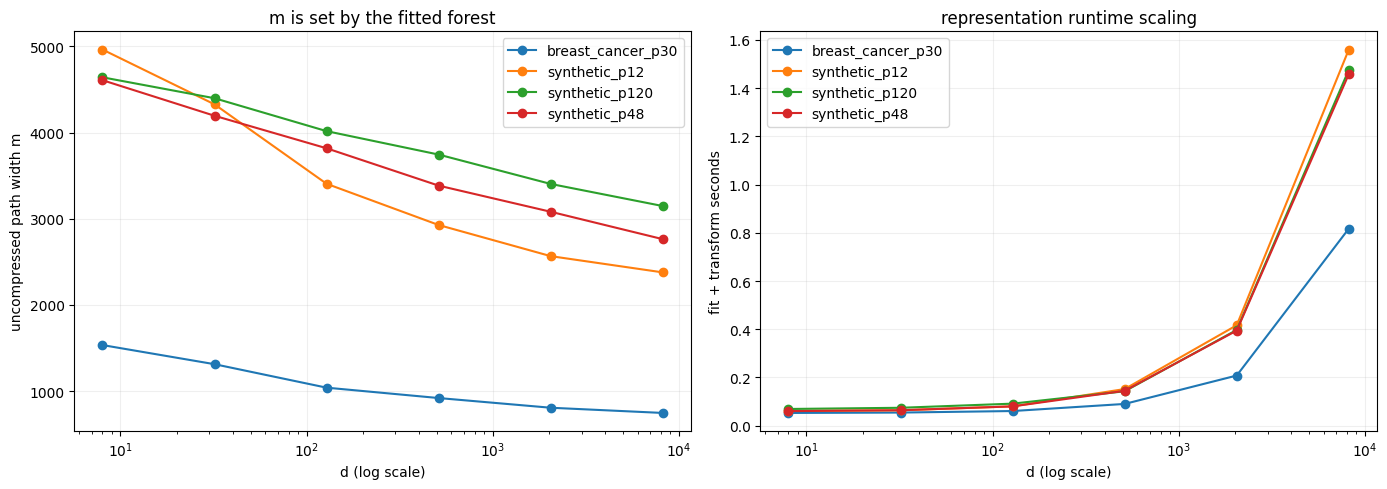

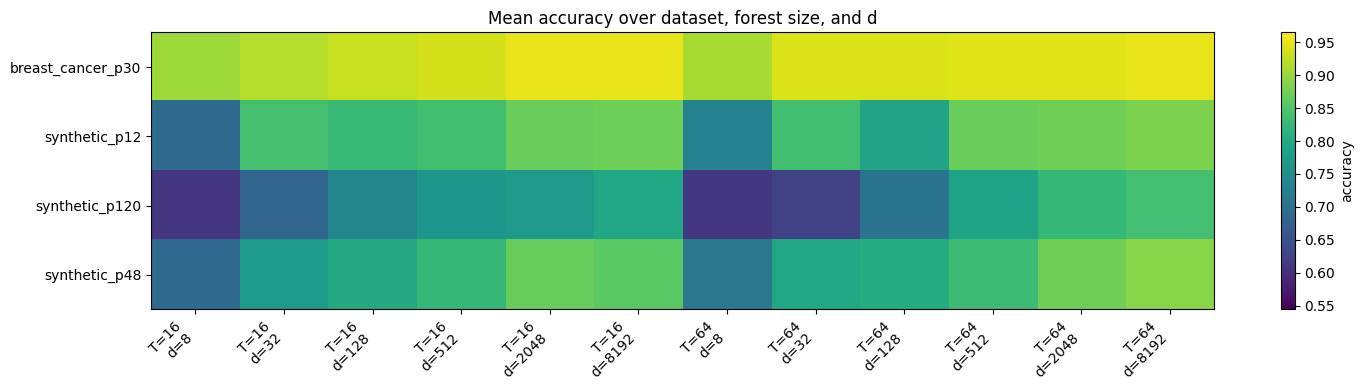

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for dataset_name, group in ok.groupby("dataset"):
    curve = group.groupby("d", as_index=False).agg(m=("m", "mean"), fit=("fit_seconds", "mean"), transform=("transform_seconds", "mean"))
    axes[0].plot(curve.d, curve.m, marker="o", label=dataset_name)
    axes[1].plot(curve["d"], curve["fit"] + curve["transform"], marker="o", label=dataset_name)
for ax in axes:
    ax.set_xscale("log")
    ax.grid(alpha=0.2)
    ax.legend()
axes[0].set_xlabel("d (log scale)")
axes[0].set_ylabel("uncompressed path width m")
axes[0].set_title("m is set by the fitted forest")
axes[1].set_xlabel("d (log scale)")
axes[1].set_ylabel("fit + transform seconds")
axes[1].set_title("representation runtime scaling")
fig.tight_layout()
plt.show()

heat = ok.pivot_table(index="dataset", columns=["n_estimators", "d"], values="forest_sketch_accuracy", aggfunc="mean")
fig, ax = plt.subplots(figsize=(15, 4))
im = ax.imshow(heat.values, aspect="auto", cmap="viridis", vmin=ok.forest_sketch_accuracy.min(), vmax=ok.forest_sketch_accuracy.max())
ax.set_yticks(range(len(heat.index)), heat.index)
ax.set_xticks(range(len(heat.columns)), [f"T={t}\nd={d}" for t, d in heat.columns], rotation=45, ha="right")
ax.set_title("Mean accuracy over dataset, forest size, and d")
fig.colorbar(im, ax=ax, label="accuracy")
fig.tight_layout()
plt.show()

## Interpretation report

The following calculations are descriptive checks, not model-selection claims. Spearman correlations are computed over successful configuration/seed rows for accuracy against `log(d)`, `log(d/p)`, and `log(d/m)`. A useful next experiment would hold out an additional dataset and select `d` using validation data rather than reading the test curves.

In [8]:
for column in ["d", "d_over_p", "d_over_m"]:
    valid = ok[[column, "forest_sketch_accuracy"]].dropna()
    rho, p_value = spearmanr(np.log(valid[column]), valid.forest_sketch_accuracy)
    print(f"Spearman rho accuracy vs log({column}) = {rho:.3f}, p={p_value:.3g}")

best = (
    ok.sort_values("forest_sketch_accuracy", ascending=False)
    .groupby(["dataset", "n_estimators"], as_index=False)
    .first()[["dataset", "n_estimators", "p", "m", "d", "d_over_p", "d_over_m", "raw_rf_accuracy", "forest_sketch_accuracy", "accuracy_gap_to_raw"]]
)
display(best.round(4))
print("\nReport template:")
print("- Does competitiveness look more stable by p, m, d/p, d/m, or neither?")
print("- Which dataset/forest combinations are exceptions, and how wide are their seed deviations?")
print("- Limitations: only classification, one downstream learner, bounded forest settings, and exploratory test-set comparisons.")
print("- Next experiment: pre-register a validation-based d selection rule and test it on held-out datasets/task types.")
print("- Conclusion: this notebook provides exploratory evidence, not a proof.")

Spearman rho accuracy vs log(d) = 0.458, p=2.73e-06
Spearman rho accuracy vs log(d_over_p) = 0.582, p=5.01e-10
Spearman rho accuracy vs log(d_over_m) = 0.549, p=6.91e-09


,dataset,n_estimators,p,m,d,d_over_p,d_over_m,raw_rf_accuracy,forest_sketch_accuracy,accuracy_gap_to_raw
0,breast_cancer_p30,16,30,342,2048,68.2667,5.9883,0.9415,0.9649,0.0234
1,breast_cancer_p30,64,30,1272,8192,273.0667,6.4403,0.9415,0.9591,0.0175
2,synthetic_p12,16,12,842,2048,170.6667,2.4323,0.8963,0.8963,0.0000
3,synthetic_p12,64,12,3872,512,42.6667,0.1322,0.9000,0.9037,0.0037
4,synthetic_p120,16,120,1276,8192,68.2667,6.4201,0.7148,0.8037,0.0889
5,synthetic_p120,64,120,5072,8192,68.2667,1.6151,0.7741,0.8444,0.0704
6,synthetic_p48,16,48,1234,2048,42.6667,1.6596,0.8667,0.8667,0.0000
7,synthetic_p48,64,48,4452,8192,170.6667,1.8401,0.8519,0.8963,0.0444



Report template:
- Does competitiveness look more stable by p, m, d/p, d/m, or neither?
- Which dataset/forest combinations are exceptions, and how wide are their seed deviations?
- Limitations: only classification, one downstream learner, bounded forest settings, and exploratory test-set comparisons.
- Next experiment: pre-register a validation-based d selection rule and test it on held-out datasets/task types.
- Conclusion: this notebook provides exploratory evidence, not a proof.
